# 🎓 Student Performance Analysis Pipeline

End-to-end data analysis: EDA → Cleaning → Validation → Feature Engineering → Visualization.

**Dataset:** Students Performance in Exams

**Goal:** Understand what factors influence student academic performance across Math, Reading, and Writing.

---
## 1. Exploratory Data Analysis (EDA)

**Goal:** Understand the dataset structure, data types, descriptive statistics, and distributions before any cleaning.

In [2]:
import pandas as pd

# ── Load Data ──
df = pd.read_csv("StudentsPerformance.csv")

print("=" * 55)
print("DATASET OVERVIEW")
print("=" * 55)
print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")
print(f"\nColumn Names:\n{list(df.columns)}")

print("\n" + "=" * 55)
print("DATA TYPES")
print("=" * 55)
print(df.dtypes)

print("\n" + "=" * 55)
print("DESCRIPTIVE STATISTICS — NUMERIC COLUMNS")
print("=" * 55)
print(df.describe().T)

print("\n" + "=" * 55)
print("MISSING VALUES")
print("=" * 55)
missing = pd.DataFrame({
    'Count'  : df.isnull().sum(),
    'Percent': (df.isnull().mean() * 100).round(2)
})
print(missing[missing['Count'] > 0].to_string() or "✅ No missing values found.")

print("\n" + "=" * 55)
print("CATEGORICAL DISTRIBUTIONS")
print("=" * 55)
cat_cols = ['gender', 'race/ethnicity', 'parental level of education',
            'lunch', 'test preparation course']
for col in cat_cols:
    if col in df.columns:
        print(f"\n{col.upper()}:\n{df[col].value_counts().to_string()}")


DATASET OVERVIEW
Rows: 1,000  |  Columns: 8

Column Names:
['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'math score', 'reading score', 'writing score']

DATA TYPES
gender                         object
race/ethnicity                 object
parental level of education    object
lunch                          object
test preparation course        object
math score                      int64
reading score                   int64
writing score                   int64
dtype: object

DESCRIPTIVE STATISTICS — NUMERIC COLUMNS
                count    mean        std   min    25%   50%   75%    max
math score     1000.0  66.089  15.163080   0.0  57.00  66.0  77.0  100.0
reading score  1000.0  69.169  14.600192  17.0  59.00  70.0  79.0  100.0
writing score  1000.0  68.054  15.195657  10.0  57.75  69.0  79.0  100.0

MISSING VALUES
Empty DataFrame
Columns: [Count, Percent]
Index: []

CATEGORICAL DISTRIBUTIONS

GENDER:
gender
female    518
male    

---
## 2. Data Cleaning

**Goal:** Standardize column names, fix data types, handle any anomalies, remove invalid rows, and ensure consistency across all columns.

In [3]:
import pandas as pd
import numpy as np

# ── Load Raw Data ──
df = pd.read_csv("StudentsPerformance.csv")

# ── Rename columns for easier access ──
df.columns = [
    'gender', 'ethnicity', 'parent_education',
    'lunch', 'test_prep', 'math_score',
    'reading_score', 'writing_score'
]
print("✅ Columns renamed successfully.")
print(f"   New column names: {list(df.columns)}")

# ── Ensure score columns are numeric ──
score_cols = ['math_score', 'reading_score', 'writing_score']
for col in score_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# ── Drop rows where any score is missing ──
before = len(df)
df = df.dropna(subset=score_cols)
print(f"Dropped {before - len(df)} rows with missing scores.")

# ── Drop rows with invalid scores (outside 0–100) ──
before = len(df)
for col in score_cols:
    df = df[(df[col] >= 0) & (df[col] <= 100)]
print(f"Dropped {before - len(df)} rows with out-of-range scores.")

# ── Standardize categorical text ──
for col in ['gender', 'ethnicity', 'parent_education', 'lunch', 'test_prep']:
    df[col] = df[col].str.strip().str.lower()
print("✅ Categorical columns standardized to lowercase.")

# ── Fill any remaining missing categoricals with 'unknown' ──
cat_cols = ['gender', 'ethnicity', 'parent_education', 'lunch', 'test_prep']
for col in cat_cols:
    filled = df[col].isnull().sum()
    df[col] = df[col].fillna('unknown')
    if filled > 0:
        print(f"  Filled {filled} missing values in '{col}' with 'unknown'.")

# ── Remove duplicates ──
before = len(df)
df = df.drop_duplicates()
print(f"Dropped {before - len(df)} duplicate rows.")

# ── Save ──
df.to_csv("cleaned_students.csv", index=False)
print(f"\n✅ Cleaning complete — final shape: {df.shape}")


✅ Columns renamed successfully.
   New column names: ['gender', 'ethnicity', 'parent_education', 'lunch', 'test_prep', 'math_score', 'reading_score', 'writing_score']
Dropped 0 rows with missing scores.
Dropped 0 rows with out-of-range scores.
✅ Categorical columns standardized to lowercase.
Dropped 0 duplicate rows.

✅ Cleaning complete — final shape: (1000, 8)


---
## 3. Data Quality Validation

**Goal:** Verify the cleaned dataset passes all business rules. Each check prints only failing records so issues are immediately actionable.

In [4]:
import pandas as pd

df = pd.read_csv("cleaned_students.csv")
issues = 0

def check(name, mask, df):
    global issues
    bad = df[mask]
    if bad.empty:
        print(f"  ✅ PASS  — {name}")
    else:
        print(f"  ❌ FAIL  — {name}: {len(bad)} record(s) affected")
        print(bad.head(3).to_string(index=True))
        issues += 1

print("=" * 55)
print("DATA QUALITY VALIDATION REPORT")
print("=" * 55)

score_cols = ['math_score', 'reading_score', 'writing_score']

for col in score_cols:
    check(f"{col} in range [0, 100]",
          (df[col] < 0) | (df[col] > 100), df)

check("No missing scores",
      df[score_cols].isnull().any(axis=1), df)

check("gender is valid",
      ~df['gender'].isin(['male', 'female']), df)

check("lunch is valid",
      ~df['lunch'].isin(['standard', 'free/reduced']), df)

check("test_prep is valid",
      ~df['test_prep'].isin(['none', 'completed']), df)

check("No duplicate rows",
      df.duplicated(), df)

print("\n" + "=" * 55)
if issues == 0:
    print("✅ ALL CHECKS PASSED — Dataset is clean and valid.")
else:
    print(f"⚠️  {issues} CHECK(S) FAILED — Review flagged records above.")
print("=" * 55)


DATA QUALITY VALIDATION REPORT
  ✅ PASS  — math_score in range [0, 100]
  ✅ PASS  — reading_score in range [0, 100]
  ✅ PASS  — writing_score in range [0, 100]
  ✅ PASS  — No missing scores
  ✅ PASS  — gender is valid
  ✅ PASS  — lunch is valid
  ✅ PASS  — test_prep is valid
  ✅ PASS  — No duplicate rows

✅ ALL CHECKS PASSED — Dataset is clean and valid.


---
## 4. Feature Engineering

**Goal:** Create new meaningful features that help uncover deeper patterns in student performance.

In [5]:
import pandas as pd
import numpy as np

df = pd.read_csv("cleaned_students.csv")

# ── Average score across all subjects ──
df['avg_score'] = df[['math_score', 'reading_score', 'writing_score']].mean(axis=1).round(2)

# ── Total score ──
df['total_score'] = df['math_score'] + df['reading_score'] + df['writing_score']

# ── Performance grade based on average score ──
def assign_grade(avg):
    if avg >= 90: return 'A'
    elif avg >= 75: return 'B'
    elif avg >= 60: return 'C'
    elif avg >= 50: return 'D'
    else: return 'F'

df['grade'] = df['avg_score'].apply(assign_grade)

# ── Strongest subject per student ──
df['strongest_subject'] = df[['math_score', 'reading_score', 'writing_score']].idxmax(axis=1)
df['strongest_subject'] = df['strongest_subject'].str.replace('_score', '')

# ── Score gap: max minus min score (how balanced is the student?) ──
df['score_gap'] = (df[['math_score', 'reading_score', 'writing_score']].max(axis=1)
                   - df[['math_score', 'reading_score', 'writing_score']].min(axis=1))

# ── Above average flag ──
global_avg = df['avg_score'].mean()
df['above_average'] = (df['avg_score'] >= global_avg).astype(int)

# ── Parent education level encoded as ordinal ──
edu_order = {
    'some high school': 1,
    'high school': 2,
    'some college': 3,
    "associate's degree": 4,
    "bachelor's degree": 5,
    "master's degree": 6
}
df['parent_edu_level'] = df['parent_education'].map(edu_order)

# ── Prepared student: completed test prep AND has standard lunch ──
df['fully_prepared'] = ((df['test_prep'] == 'completed') & (df['lunch'] == 'standard')).astype(int)

print(f"Features added: {df.shape[1]} total columns")
print("\nNew columns preview:")
new_cols = ['avg_score', 'total_score', 'grade', 'strongest_subject',
            'score_gap', 'above_average', 'parent_edu_level', 'fully_prepared']
print(df[new_cols].head(8).to_string(index=False))

print("\nGrade Distribution:")
print(df['grade'].value_counts().sort_index().to_string())

df.to_csv("featured_students.csv", index=False)
print("\n✅ Feature engineering complete.")


Features added: 16 total columns

New columns preview:
 avg_score  total_score grade strongest_subject  score_gap  above_average  parent_edu_level  fully_prepared
     72.67          218     C           writing          2              1                 5               0
     82.33          247     B           reading         21              1                 3               1
     92.67          278     A           reading          5              1                 6               0
     49.33          148     F           reading         13              0                 4               0
     76.33          229     B           reading          3              1                 3               0
     77.33          232     B           reading         12              1                 4               0
     91.67          275     A           reading          7              1                 3               1
     40.67          122     F           reading          4              0        

---
## 5. Business Insights & Visualizations

**Goal:** Communicate five key findings about student performance using clear, professional charts.

Insight 1: Students who completed test prep scored 5.6 pts higher in Math.
Insight 2: Male avg = 65.8, Female avg = 69.6
Insight 3: Students whose parents have 'master's degree' score highest on average.
Insight 4: Most students fall in grade 'C' (391 students).
Insight 5: Students with standard lunch score 11.1 pts more in Math than free/reduced lunch.


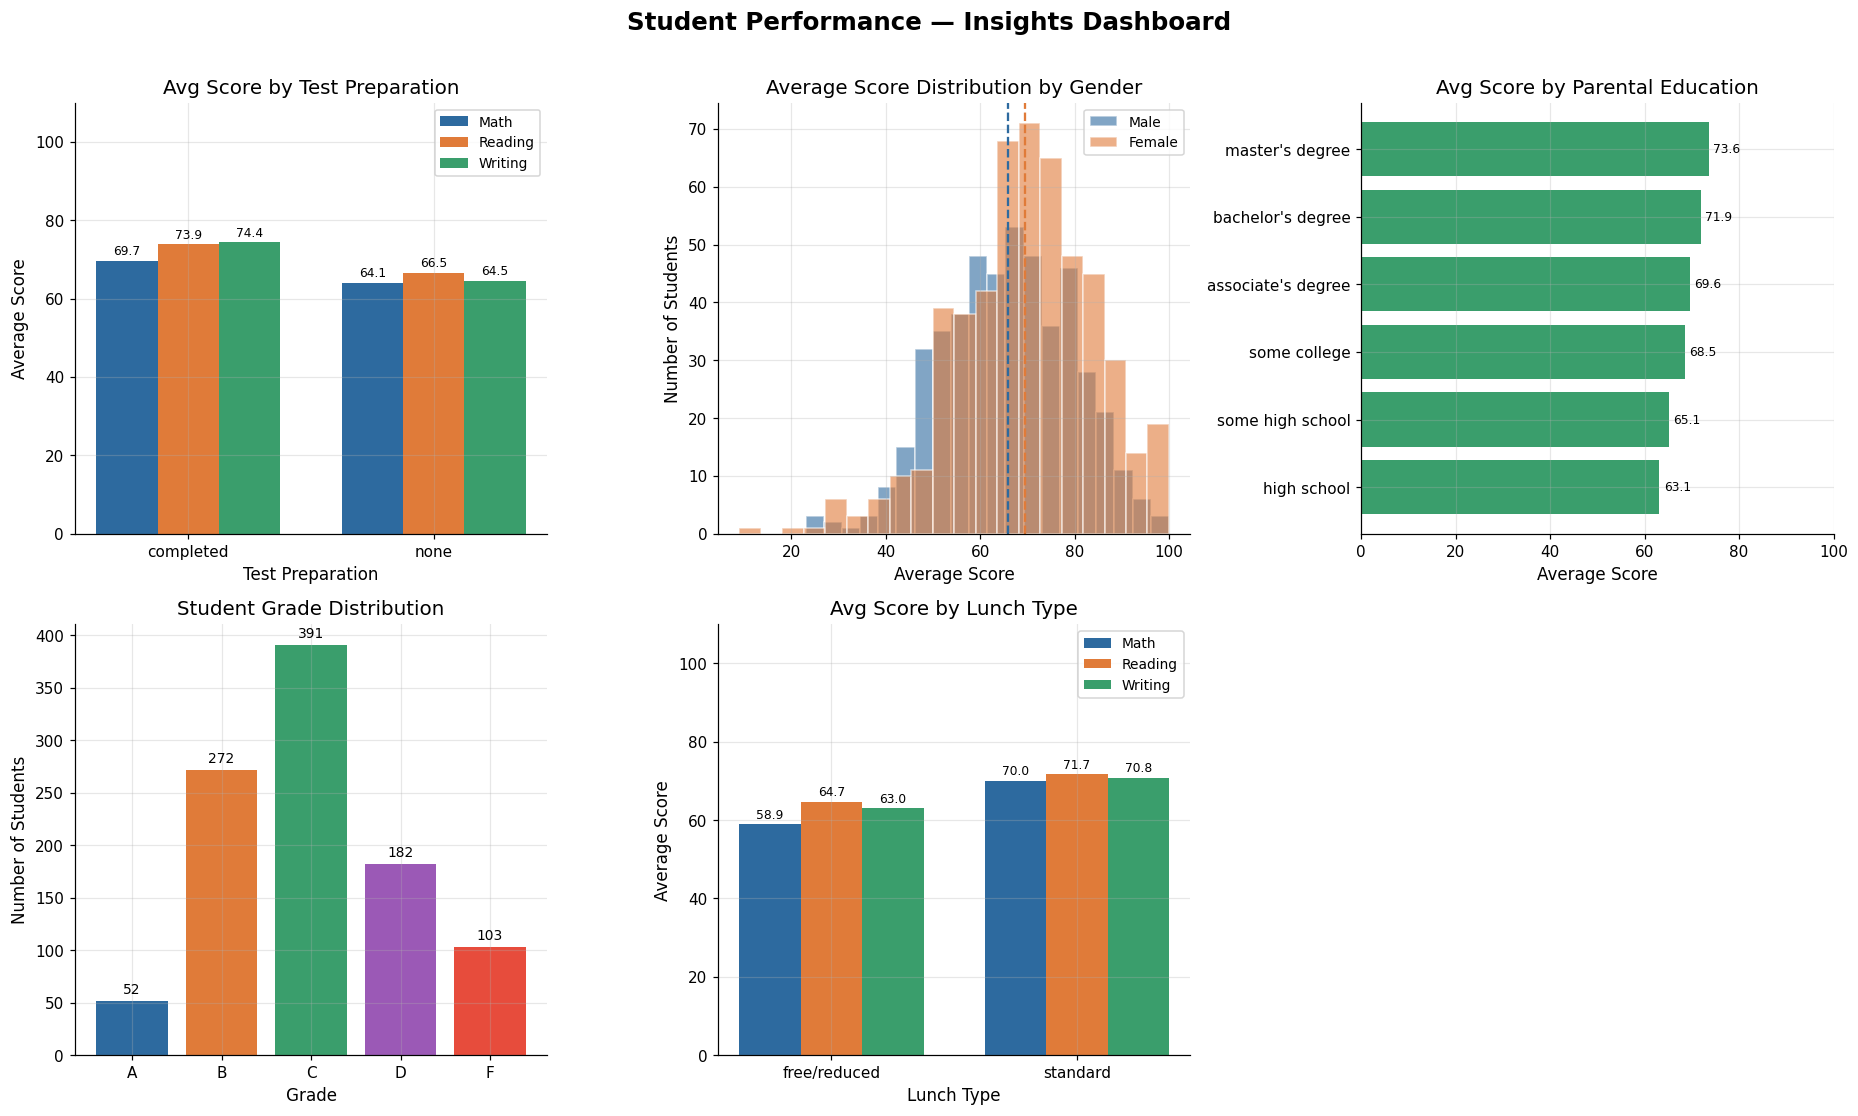


✅ Dashboard saved as dashboard.png


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# ── Styling ──
plt.rcParams.update({
    'figure.dpi'       : 110,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.alpha'       : 0.3,
    'axes.titlesize'   : 13,
    'axes.labelsize'   : 11,
    'font.family'      : 'sans-serif',
})
PALETTE = ['#2D6A9F', '#E07B39', '#3A9E6C', '#9B59B6', '#E74C3C']

df = pd.read_csv("featured_students.csv")

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle("Student Performance — Insights Dashboard", fontsize=16, fontweight='bold', y=1.01)
axes_flat = axes.flatten()

# ── 1. Average Score by Test Preparation ──
ax = axes_flat[0]
prep_avg = df.groupby('test_prep')[['math_score','reading_score','writing_score']].mean()
x = np.arange(len(prep_avg.index))
width = 0.25
for i, (col, color) in enumerate(zip(prep_avg.columns, PALETTE)):
    bars = ax.bar(x + i*width, prep_avg[col], width, label=col.replace('_score','').title(), color=color)
    ax.bar_label(bars, fmt='{:.1f}', fontsize=8, padding=2)
ax.set_title("Avg Score by Test Preparation")
ax.set_xlabel("Test Preparation")
ax.set_ylabel("Average Score")
ax.set_xticks(x + width)
ax.set_xticklabels(prep_avg.index)
ax.legend(fontsize=9)
ax.set_ylim(0, 110)

diff = prep_avg.loc['completed','math_score'] - prep_avg.loc['none','math_score']
print(f"Insight 1: Students who completed test prep scored {diff:.1f} pts higher in Math.")

# ── 2. Score Distribution by Gender ──
ax = axes_flat[1]
male_avg   = df[df['gender']=='male']['avg_score']
female_avg = df[df['gender']=='female']['avg_score']
ax.hist(male_avg,   bins=20, alpha=0.6, color=PALETTE[0], label='Male',   edgecolor='white')
ax.hist(female_avg, bins=20, alpha=0.6, color=PALETTE[1], label='Female', edgecolor='white')
ax.axvline(male_avg.mean(),   color=PALETTE[0], linestyle='--', linewidth=1.5)
ax.axvline(female_avg.mean(), color=PALETTE[1], linestyle='--', linewidth=1.5)
ax.set_title("Average Score Distribution by Gender")
ax.set_xlabel("Average Score")
ax.set_ylabel("Number of Students")
ax.legend(fontsize=9)

print(f"Insight 2: Male avg = {male_avg.mean():.1f}, Female avg = {female_avg.mean():.1f}")

# ── 3. Avg Score by Parental Education Level ──
ax = axes_flat[2]
edu_avg = df.groupby('parent_education')['avg_score'].mean().sort_values(ascending=True)
bars = ax.barh(edu_avg.index, edu_avg.values, color=PALETTE[2])
ax.bar_label(bars, fmt='{:.1f}', padding=3, fontsize=8)
ax.set_title("Avg Score by Parental Education")
ax.set_xlabel("Average Score")
ax.set_xlim(0, 100)

top_edu = edu_avg.idxmax()
print(f"Insight 3: Students whose parents have '{top_edu}' score highest on average.")

# ── 4. Grade Distribution ──
ax = axes_flat[3]
grade_order = ['A', 'B', 'C', 'D', 'F']
grade_counts = df['grade'].value_counts().reindex(grade_order, fill_value=0)
bars = ax.bar(grade_counts.index, grade_counts.values, color=PALETTE[:5])
ax.bar_label(bars, fmt='{:,.0f}', fontsize=9, padding=3)
ax.set_title("Student Grade Distribution")
ax.set_xlabel("Grade")
ax.set_ylabel("Number of Students")

top_grade = grade_counts.idxmax()
print(f"Insight 4: Most students fall in grade '{top_grade}' ({grade_counts[top_grade]} students).")

# ── 5. Lunch Type vs Average Score ──
ax = axes_flat[4]
lunch_avg = df.groupby('lunch')[['math_score','reading_score','writing_score']].mean()
x = np.arange(len(lunch_avg.index))
for i, (col, color) in enumerate(zip(lunch_avg.columns, PALETTE)):
    bars = ax.bar(x + i*width, lunch_avg[col], width, label=col.replace('_score','').title(), color=color)
    ax.bar_label(bars, fmt='{:.1f}', fontsize=8, padding=2)
ax.set_title("Avg Score by Lunch Type")
ax.set_xlabel("Lunch Type")
ax.set_ylabel("Average Score")
ax.set_xticks(x + width)
ax.set_xticklabels(lunch_avg.index)
ax.legend(fontsize=9)
ax.set_ylim(0, 110)

diff_lunch = lunch_avg.loc['standard','math_score'] - lunch_avg.loc['free/reduced','math_score']
print(f"Insight 5: Students with standard lunch score {diff_lunch:.1f} pts more in Math than free/reduced lunch.")

# ── Hide unused 6th panel ──
axes_flat[5].set_visible(False)

plt.tight_layout()
plt.savefig("dashboard.png", bbox_inches='tight', dpi=130)
plt.show()
print("\n✅ Dashboard saved as dashboard.png")
